# Amazon Product Reviews - Text Classification

**Course:** Text Analytics  
**Dataset source:** https://www.kaggle.com/datasets/karkavelrajaj/amazon-sales-dataset

This notebook takes customer reviews from Amazon and builds a model that can tell apart
products that customers are happy with from products that need improvement.
I do this in four steps: load the data, clean the text, turn the text into numbers,
and then train and test a classifier.


## Section 1: Load the data and build the label

First I load the dataset and look at its size and columns.
Then I create the label (target) that the model will try to predict.


In [26]:
# Libraries for loading and handling the data
import pandas as pd
import numpy as np

# Load the Amazon dataset. Change this path if your CSV is saved somewhere else.
df = pd.read_csv('amazon.csv')  # download from the Kaggle link in the README, place it next to this notebook

# How many rows and columns do we have?
print(f"Dataset Shape: {df.shape}")

# Look at the first few rows to see what the data looks like
df.head()

Dataset Shape: (1465, 16)


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [27]:
# Check if the two columns I care about have any missing values
print("Missing values per column:")
print(df[['review_content', 'rating']].isnull().sum())

# The rating column sometimes has text mixed in, so I turn it into a proper number.
# Anything that cannot become a number becomes NaN.
df['rating_clean'] = pd.to_numeric(df['rating'], errors='coerce')

# Drop rows that have no review text or no valid rating
df = df.dropna(subset=['review_content', 'rating_clean']).copy()

# Build the label:
# rating 4.0 or higher  -> 1  (customers are satisfied)
# rating below 4.0       -> 0  (product needs improvement)
df['target'] = (df['rating_clean'] >= 4.0).astype(int)

# See how the two classes are split
print("\nTarget Class Distribution:")
print(df['target'].value_counts(normalize=True))

Missing values per column:
review_content    0
rating            0
dtype: int64

Target Class Distribution:
target
1    0.758197
0    0.241803
Name: proportion, dtype: float64


**What I did here and why**

I loaded the data and checked its shape to be sure the review and rating columns are there.
Ratings in raw online data are often stored as text, so I converted the rating column into
a real number and removed any rows that were empty. Finally I created a simple two-class label:
products rated 4.0 and above are "satisfied", and everything below 4.0 (including the average
3-star products) is "needs improvement". This turns the business question into a normal
classification task.

One thing worth noting: in this dataset each row is a product, and its review text is a
collection of several customer reviews joined together, with one overall product rating.
So the model is really learning to sort products by their rating level based on what customers
wrote about them.


## Section 2: Clean the review text

Raw reviews are messy. They have capital letters, links, numbers and punctuation that do not
help the model. In this step I clean the text and reduce each word to its base form.


In [28]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download the word lists that NLTK needs
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Set up the lemmatizer and the list of common English words to remove
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # 1. Make everything lowercase
    text = str(text).lower()

    # 2. Remove links, HTML tags, then keep only letters and spaces
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-z\s]', '', text)   # keep letters a-z and spaces only

    # 3. Split the text into single words
    words = text.split()

    # 4. Drop common/short words and reduce the rest to their base form
    cleaned_words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words and len(word) > 2
    ]

    # Join the cleaned words back into one string
    return ' '.join(cleaned_words)

# Apply the cleaning to every review
df['cleaned_review'] = df['review_content'].apply(preprocess_text)

# Compare the raw text with the cleaned text
df[['review_content', 'cleaned_review']].head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ibrah\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ibrah\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\ibrah\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


,review_content,cleaned_review
0,Looks durable Charging is fine tooNo complains...,look durable charging fine toono complainschar...
1,I ordered this cable to connect my phone to An...,ordered cable connect phone android auto car c...
2,"Not quite durable and sturdy,https://m.media-a...",quite durable sturdy good nice productworking ...
3,"Good product,long wire,Charges good,Nice,I bou...",good productlong wirecharges goodnicei bought ...
4,"Bought this instead of original apple, does th...",bought instead original apple work fast apple ...


**What I did here and why**

I cleaned the reviews so the model can focus on the words that actually carry meaning.
Making the text lowercase means "Good" and "good" are treated as the same word. I removed
links, HTML and anything that is not a letter, because symbols and numbers add noise.
I also removed common words like "the" and "is" (stop words) since they appear everywhere and
do not tell us if a review is positive or negative. Finally I used lemmatization, which turns
words like "running" into "run", so different forms of the same word are counted together.

*(Small fix from an earlier version: the letter filter now correctly keeps only `a-z`. The
earlier `A-r` range was a typo.)*


## Section 3: Turn the text into numbers (TF-IDF) and split the data

A model cannot read words, so I convert the cleaned reviews into numbers using TF-IDF.
TF-IDF gives more weight to words that are important in a review but not too common overall.
Then I split the data into a training part and a testing part.


In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Turn text into numbers. I keep the top 3000 words and also look at word pairs (bigrams).
tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1, 2))

# X = the numbers from the reviews, y = the label
X = tfidf.fit_transform(df['cleaned_review'])
y = df['target'].values

# Use 80% of the data to train and keep 20% to test.
# stratify keeps the same class balance in both parts.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training feature matrix shape: {X_train.shape}")
print(f"Testing feature matrix shape:  {X_test.shape}")

Training feature matrix shape: (1171, 3000)
Testing feature matrix shape:  (293, 3000)


**What I did here and why**

TF-IDF is a common way to represent text for machine learning. It counts how often a word
appears in a review, but lowers the weight of words that show up in almost every review, so
the model pays attention to the words that really separate one product from another. I limited
it to the 3000 most useful words and also included two-word phrases (bigrams) like "value money".
Splitting the data into training and testing lets me check the model on reviews it has never
seen, which is a fairer test of how well it works.


## Section 4: Train the classifier and check the results

Now I train a Logistic Regression model and measure how well it performs using accuracy,
precision, recall and a confusion matrix.


Overall Model Accuracy: 77.47%

Classification Report:
                       precision    recall  f1-score   support

Neutral/Negative (<4)       0.53      0.66      0.59        71
       Positive (>=4)       0.88      0.81      0.85       222

             accuracy                           0.77       293
            macro avg       0.71      0.74      0.72       293
         weighted avg       0.80      0.77      0.78       293



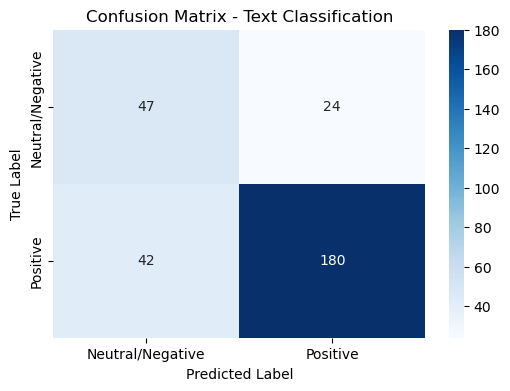

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Logistic Regression. class_weight='balanced' helps because we have fewer negative reviews.
model = LogisticRegression(class_weight='balanced', random_state=42)

# Train the model
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Overall accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Overall Model Accuracy: {acc * 100:.2f}%\n")

# Detailed report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Neutral/Negative (<4)', 'Positive (>=4)']))

# Confusion matrix as a heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Neutral/Negative', 'Positive'],
            yticklabels=['Neutral/Negative', 'Positive'])
plt.title('Confusion Matrix - Text Classification')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

**What I did here and why**

I chose Logistic Regression because it works well with text data, it is fast, and it is easy
to explain, which matters for a business report. Because there are more positive reviews than
negative ones, I set `class_weight='balanced'` so the model does not simply ignore the smaller
negative group. I looked at more than accuracy: precision tells me how many of the flagged
negative reviews were truly negative, and recall tells me how many of the real negative reviews
the model managed to catch. Recall on the negative class is the number I care about most here,
because the goal is to catch unhappy customers.


In [31]:
# Look at which words push a review towards negative or positive
feature_names = np.array(tfidf.get_feature_names_out())
coefficients = model.coef_[0]

# Most negative and most positive words
top_negative_indices = np.argsort(coefficients)[:10]
top_positive_indices = np.argsort(coefficients)[-10:]

print("Top 10 Key Words Driving Neutral/Negative Ratings (<4 Stars):")
for idx in top_negative_indices:
    print(f"- {feature_names[idx]} (Weight: {coefficients[idx]:.4f})")

print("\nTop 10 Key Words Driving Positive Ratings (>=4 Stars):")
for idx in reversed(top_positive_indices):
    print(f"- {feature_names[idx]} (Weight: {coefficients[idx]:.4f})")

Top 10 Key Words Driving Neutral/Negative Ratings (<4 Stars):
- remote (Weight: -1.8334)
- jar (Weight: -1.5679)
- ear (Weight: -1.2180)
- poor (Weight: -1.2056)
- bud (Weight: -1.0502)
- product useful (Weight: -0.9895)
- useful (Weight: -0.9891)
- month (Weight: -0.9784)
- warm (Weight: -0.9783)
- hair (Weight: -0.9616)

Top 10 Key Words Driving Positive Ratings (>=4 Stars):
- cable (Weight: 2.0679)
- speed (Weight: 1.4336)
- easy (Weight: 1.4113)
- perfect (Weight: 1.2289)
- mouse (Weight: 1.1879)
- got (Weight: 1.1080)
- excellent (Weight: 1.0635)
- otherwise (Weight: 1.0632)
- fast (Weight: 1.0069)
- installation (Weight: 0.9631)


**What I did here and why**

One nice thing about Logistic Regression is that I can open it up and see which words matter.
Words with strong negative weights are the ones linked to lower-rated products, and words with
strong positive weights are linked to the products customers liked. This gives management a
direct, practical list of what people complain about and what they praise, instead of a black box.
